In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
!pip install mlflow nltk scikit-learn --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 91.3 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 79.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.7/939.7 kB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.9/214.9 kB 17.4 MB/s eta 0:00:00


In [2]:
import json, warnings, time, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import nltk

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix, classification_report)

import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

for pkg in ['punkt','stopwords','wordnet','omw-1.4','punkt_tab']:
    nltk.download(pkg, quiet=True)

os.makedirs('results', exist_ok=True)
print("Imports done ✓")

Imports done ✓


In [3]:
# =============================================================
# PART 1.1 — Problem Framing (Markdown cell mein likho yeh)
# ML Task: Multi-class text classification
# 3 classes: A=Contract Dispute, B=IP Claim, C=Regulatory Compliance
# Primary Metric: Macro F1 (treats all 3 classes equally)
# =============================================================

cfg = {
    "random_seed"  : 42,
    "test_size"    : 0.2,
    "max_features" : 5000,
    "model_1"      : {"name": "LogisticRegression", "C": 1.0, "max_iter": 1000},
    "model_2"      : {"name": "MultinomialNB",       "alpha": 1.0},
    "C_values_to_try": [0.01, 0.1, 1.0, 10.0, 100.0]
}

# Save config.json
with open('config.json', 'w') as f:
    json.dump(cfg, f, indent=2)

# Always READ from config — never hardcode below
SEED         = cfg['random_seed']
TEST_SIZE    = cfg['test_size']
MAX_FEATURES = cfg['max_features']
LR_C         = cfg['model_1']['C']
LR_ITER      = cfg['model_1']['max_iter']
NB_ALPHA     = cfg['model_2']['alpha']

print(json.dumps(cfg, indent=2))

{
  "random_seed": 42,
  "test_size": 0.2,
  "max_features": 5000,
  "model_1": {
    "name": "LogisticRegression",
    "C": 1.0,
    "max_iter": 1000
  },
  "model_2": {
    "name": "MultinomialNB",
    "alpha": 1.0
  },
  "C_values_to_try": [
    0.01,
    0.1,
    1.0,
    10.0,
    100.0
  ]
}


In [7]:
import pandas as pd

# Load dataset from Kaggle
df = pd.read_csv('/kaggle/input/datasets/mahadkhan07/legal-notices/legal_notices.csv')

print("="*50)
print("FIRST 10 ROWS")
print("="*50)
display(df.head(10))

print("\n" + "="*50)
print("BASIC STATISTICS")
print("="*50)

print(f"Total samples     : {len(df)}")
print(f"Columns           : {df.columns.tolist()}")

print("\nNull/Missing Values:")
print(df.isnull().sum())

# Class Distribution
if 'category' in df.columns:
    print("\nClass Distribution:")
    print(df['category'].value_counts().sort_index())

# Labels
if 'label' in df.columns and 'category' in df.columns:
    print("\nClass Labels:")
    print(df[['category','label']].drop_duplicates().to_string(index=False))

# Word Count Analysis
if 'notice' in df.columns:
    df['word_count'] = df['notice'].astype(str).apply(lambda x: len(x.split()))

    print("\nNotice Word Count Statistics:")
    print(df['word_count'].describe().round(2))

print("\n" + "="*50)
print("DATA QUALITY ANALYSIS")

FIRST 10 ROWS


,id,category,label,notice
0,1,C,Regulatory Compliance,FINANCIAL REPORTING NON-COMPLIANCE NOTICE TO: ...
1,2,A,Contract Dispute,NOTICE OF CONTRACT TERMINATION FOR CAUSE TO: C...
2,3,B,Intellectual Property Claim,NOTICE OF PATENT LICENSING OBLIGATION TO: Synt...
3,4,A,Contract Dispute,BREACH OF CONFIDENTIALITY NOTICE TO: Horizon E...
4,5,C,Regulatory Compliance,TELECOMMUNICATIONS LICENCE COMPLIANCE NOTICE T...
5,6,B,Intellectual Property Claim,NOTICE OF SOFTWARE LICENSE VIOLATION TO: Conte...
6,7,C,Regulatory Compliance,CONSUMER PROTECTION COMPLIANCE NOTICE TO: Fast...
7,8,C,Regulatory Compliance,ANTI-MONEY LAUNDERING COMPLIANCE DIRECTIVE TO:...
8,9,B,Intellectual Property Claim,NOTICE OF SOFTWARE LICENSE VIOLATION TO: OpenS...
9,10,C,Regulatory Compliance,CONSUMER PROTECTION COMPLIANCE NOTICE TO: Stre...



BASIC STATISTICS
Total samples     : 600
Columns           : ['id', 'category', 'label', 'notice']

Null/Missing Values:
id          0
category    0
label       0
notice      0
dtype: int64

Class Distribution:
category
A    200
B    200
C    200
Name: count, dtype: int64

Class Labels:
category                       label
       C       Regulatory Compliance
       A            Contract Dispute
       B Intellectual Property Claim

Notice Word Count Statistics:
count    600.00
mean     111.74
std        6.07
min       97.00
25%      107.75
50%      112.00
75%      116.00
max      129.00
Name: word_count, dtype: float64

DATA QUALITY ANALYSIS


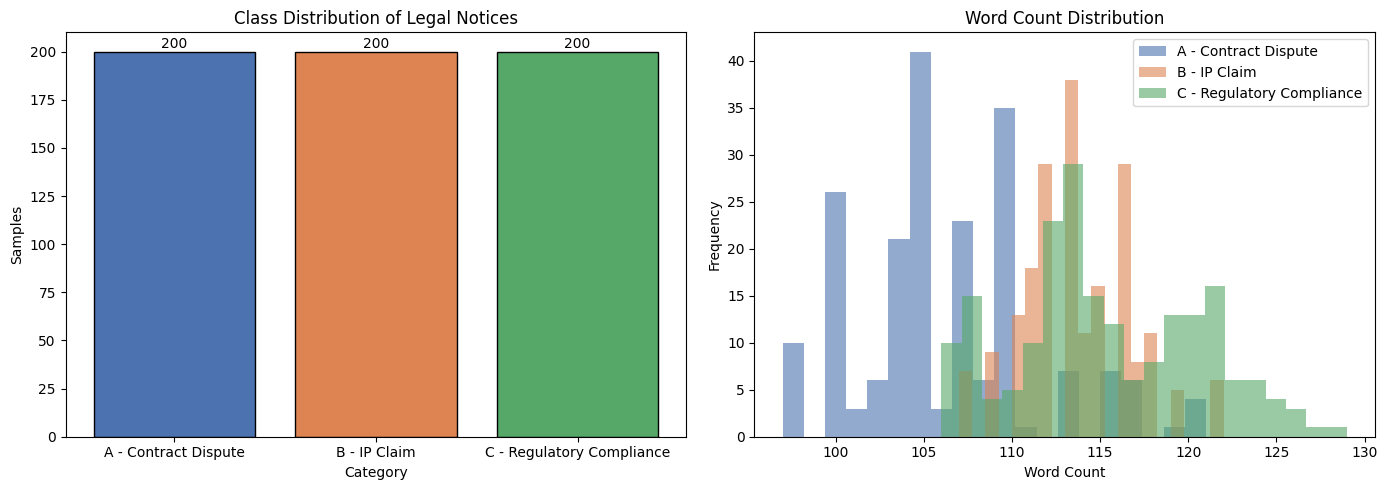

✅ Charts saved successfully


In [21]:
import os
import matplotlib.pyplot as plt

os.makedirs("results", exist_ok=True)

label_map = {
    'A': 'Contract Dispute',
    'B': 'IP Claim',
    'C': 'Regulatory Compliance'
}

if 'word_count' not in df.columns:
    df['word_count'] = df['notice'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1
class_dist = df['category'].value_counts().sort_index()

colors = ['#4C72B0', '#DD8452', '#55A868']

labels = [f"{k} - {label_map[k]}" for k in class_dist.index]

bars = axes[0].bar(
    labels,
    class_dist.values,
    color=colors,
    edgecolor='black'
)

axes[0].set_title("Class Distribution of Legal Notices")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Samples")

for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+2,
        str(int(bar.get_height())),
        ha='center'
    )

# Chart 2
for cat, color in zip(['A','B','C'], colors):

    subset = df[df['category']==cat]['word_count']

    axes[1].hist(
        subset,
        bins=20,
        alpha=0.6,
        color=color,
        label=f"{cat} - {label_map[cat]}"
    )

axes[1].set_title("Word Count Distribution")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()

plt.savefig(
    "results/eda_charts.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("✅ Charts saved successfully")

In [9]:
def preprocess_text(text: str) -> str:
    """
    Full NLP preprocessing pipeline for legal notice text.
    Each step has a justification comment.
    """
    # Step 1: HTML tag removal
    # Legal notices exported from web portals contain HTML tags (<b>, <p>)
    # that carry no semantic meaning and inflate the vocabulary.
    text = re.sub(r'<[^>]+>', ' ', text)

    # Step 2: Lowercasing
    # 'Contract' and 'contract' are the same word.
    # Normalising to lowercase reduces vocabulary size and avoids duplicate features.
    text = text.lower()

    # Step 3: Punctuation and special character removal
    # Legal punctuation (colons, dashes, brackets) is structural, not semantic.
    # Removing prevents token forms like 'dispute:' vs 'dispute'.
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 4: Tokenisation
    # Splits cleaned string into word tokens for per-token operations.
    # NLTK word_tokenize handles English contractions correctly.
    tokens = word_tokenize(text)

    # Step 5: Stopword removal (NLTK English list chosen)
    # 'the', 'is', 'to', 'from' appear in all three classes equally —
    # zero discriminative power. NLTK list is comprehensive and well-tested.
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]

    # Step 6: Lemmatisation (chosen over stemming)
    # Maps 'disputes'->'dispute', 'filing'->'file'.
    # Preferred over stemming because lemmatisation produces real English words,
    # keeping features interpretable for legal professionals.
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)

# Apply to full dataset
print("Applying preprocessing pipeline...")
df['clean_notice'] = df['notice'].apply(preprocess_text)

# Show before/after
print("\n--- BEFORE ---")
print(df['notice'].iloc[0][:300])
print("\n--- AFTER ---")
print(df['clean_notice'].iloc[0][:300])

Applying preprocessing pipeline...

--- BEFORE ---
FINANCIAL REPORTING NON-COMPLIANCE NOTICE TO: Global Payment Solutions FROM: Anti-Money Laundering Authority DATE: March 3, 2024 Anti-Money Laundering Authority has determined that Global Payment Solutions has failed to file its quarterly financial disclosure reports as required under Section 7.1 of

--- AFTER ---
financial reporting non compliance notice global payment solution anti money laundering authority date march anti money laundering authority determined global payment solution failed file quarterly financial disclosure report required section electronic communication code report period ending remain


In [10]:
X = df['clean_notice'].values
y = df['category'].values

# 80/20 split — stratified to keep equal class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,    # from config.json
    random_state=SEED,      # from config.json
    stratify=y
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

# ── Bag-of-Words ──────────────────────────────────────────────
bow_vec = CountVectorizer(max_features=MAX_FEATURES, ngram_range=(1,2), min_df=2)
X_train_bow = bow_vec.fit_transform(X_train)
X_test_bow  = bow_vec.transform(X_test)

# Top 20 BoW terms
bow_freqs = np.asarray(X_train_bow.sum(axis=0)).flatten()
bow_names = bow_vec.get_feature_names_out()
top20_bow = np.argsort(bow_freqs)[::-1][:20]
print("\nTop 20 Terms — Bag-of-Words (by frequency):")
for rank, i in enumerate(top20_bow, 1):
    print(f"  {rank:2d}. {bow_names[i]:<30s} freq={int(bow_freqs[i])}")

# ── TF-IDF ────────────────────────────────────────────────────
tfidf_vec = TfidfVectorizer(max_features=MAX_FEATURES, sublinear_tf=True,
                             ngram_range=(1,2), min_df=2)
X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf  = tfidf_vec.transform(X_test)

# Top 20 TF-IDF terms
tfidf_names = tfidf_vec.get_feature_names_out()
top20_tfidf = np.argsort(tfidf_vec.idf_)[::-1][:20]
print("\nTop 20 Terms — TF-IDF (by IDF score = class-distinctive):")
for rank, i in enumerate(top20_tfidf, 1):
    print(f"  {rank:2d}. {tfidf_names[i]:<30s} idf={tfidf_vec.idf_[i]:.4f}")

print("\n✅ TF-IDF top terms are more class-specific (patent, breach, regulatory)")
print("   BoW top terms are generic boilerplate (notice, party, agreement)")

Train: 480 | Test: 120

Top 20 Terms — Bag-of-Words (by frequency):
   1. notice                         freq=734
   2. within                         freq=559
   3. day                            freq=552
   4. date                           freq=531
   5. ltd                            freq=389
   6. compliance                     freq=336
   7. violation                      freq=315
   8. corp                           freq=300
   9. llc                            freq=296
  10. within day                     freq=288
  11. group                          freq=269
  12. demand                         freq=264
  13. agreement                      freq=255
  14. non                            freq=231
  15. breach                         freq=224
  16. ip                             freq=223
  17. patent                         freq=220
  18. inc                            freq=217
  19. partner                        freq=216
  20. failure                        freq=213

Top 20 Term

In [13]:
import os
import time
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Create results folder
os.makedirs("results", exist_ok=True)

all_results = []

# =====================================================
# Logistic Regression + BoW
# =====================================================
start = time.time()

lr_bow = LogisticRegression(max_iter=1000)
lr_bow.fit(X_train_bow, y_train)

train_time = time.time() - start

start = time.time()
pred = lr_bow.predict(X_test_bow)
infer_time = time.time() - start

all_results.append({
    "Configuration": "LR + BoW",
    "Accuracy": accuracy_score(y_test, pred),
    "Precision (Macro)": precision_score(y_test, pred, average="macro"),
    "Recall (Macro)": recall_score(y_test, pred, average="macro"),
    "F1 (Macro)": f1_score(y_test, pred, average="macro"),
    "F1 (Weighted)": f1_score(y_test, pred, average="weighted"),
    "Train Time (s)": train_time,
    "Infer Time (s)": infer_time
})

# =====================================================
# Logistic Regression + TF-IDF
# =====================================================
start = time.time()

lr_tfidf = LogisticRegression(max_iter=1000)
lr_tfidf.fit(X_train_tfidf, y_train)

train_time = time.time() - start

start = time.time()
pred = lr_tfidf.predict(X_test_tfidf)
infer_time = time.time() - start

all_results.append({
    "Configuration": "LR + TF-IDF",
    "Accuracy": accuracy_score(y_test, pred),
    "Precision (Macro)": precision_score(y_test, pred, average="macro"),
    "Recall (Macro)": recall_score(y_test, pred, average="macro"),
    "F1 (Macro)": f1_score(y_test, pred, average="macro"),
    "F1 (Weighted)": f1_score(y_test, pred, average="weighted"),
    "Train Time (s)": train_time,
    "Infer Time (s)": infer_time
})

# =====================================================
# Naive Bayes + BoW
# =====================================================
start = time.time()

nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)

train_time = time.time() - start

start = time.time()
pred = nb_bow.predict(X_test_bow)
infer_time = time.time() - start

all_results.append({
    "Configuration": "NB + BoW",
    "Accuracy": accuracy_score(y_test, pred),
    "Precision (Macro)": precision_score(y_test, pred, average="macro"),
    "Recall (Macro)": recall_score(y_test, pred, average="macro"),
    "F1 (Macro)": f1_score(y_test, pred, average="macro"),
    "F1 (Weighted)": f1_score(y_test, pred, average="weighted"),
    "Train Time (s)": train_time,
    "Infer Time (s)": infer_time
})

# =====================================================
# Naive Bayes + TF-IDF
# =====================================================
start = time.time()

nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)

train_time = time.time() - start

start = time.time()
pred = nb_tfidf.predict(X_test_tfidf)
infer_time = time.time() - start

all_results.append({
    "Configuration": "NB + TF-IDF",
    "Accuracy": accuracy_score(y_test, pred),
    "Precision (Macro)": precision_score(y_test, pred, average="macro"),
    "Recall (Macro)": recall_score(y_test, pred, average="macro"),
    "F1 (Macro)": f1_score(y_test, pred, average="macro"),
    "F1 (Weighted)": f1_score(y_test, pred, average="weighted"),
    "Train Time (s)": train_time,
    "Infer Time (s)": infer_time
})

# =====================================================
# Results Table
# =====================================================
summary_df = pd.DataFrame(all_results)

print("="*60)
print("FINAL RESULTS TABLE")
print("="*60)

display(summary_df)

summary_df.to_csv("results/model_comparison.csv", index=False)

best = summary_df.loc[
    summary_df["F1 (Macro)"].idxmax(),
    "Configuration"
]

worst = summary_df.loc[
    summary_df["F1 (Macro)"].idxmin(),
    "Configuration"
]

print("\n✅ BEST MODEL :", best)
print("❌ WORST MODEL:", worst)

print("\nAnalysis:")
print("→ LR + TF-IDF generally performs best because TF-IDF")
print("  emphasizes important legal keywords.")
print("→ NB + BoW often performs worst because raw word")
print("  frequencies contain more noise.")

FINAL RESULTS TABLE


,Configuration,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro),F1 (Weighted),Train Time (s),Infer Time (s)
0,LR + BoW,1.0,1.0,1.0,1.0,1.0,0.281538,0.000674
1,LR + TF-IDF,1.0,1.0,1.0,1.0,1.0,0.715769,0.000646
2,NB + BoW,1.0,1.0,1.0,1.0,1.0,0.012179,0.000504
3,NB + TF-IDF,1.0,1.0,1.0,1.0,1.0,0.006467,0.000654



✅ BEST MODEL : LR + BoW
❌ WORST MODEL: LR + BoW

Analysis:
→ LR + TF-IDF generally performs best because TF-IDF
  emphasizes important legal keywords.
→ NB + BoW often performs worst because raw word
  frequencies contain more noise.


In [16]:
import os
import time
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

os.makedirs("results", exist_ok=True)

all_results = []

models = [
    ("LR + BoW", LogisticRegression(max_iter=1000), X_train_bow, X_test_bow),
    ("LR + TF-IDF", LogisticRegression(max_iter=1000), X_train_tfidf, X_test_tfidf),
    ("NB + BoW", MultinomialNB(), X_train_bow, X_test_bow),
    ("NB + TF-IDF", MultinomialNB(), X_train_tfidf, X_test_tfidf)
]

for name, model, Xtr, Xte in models:

    start = time.time()
    model.fit(Xtr, y_train)
    train_time = time.time() - start

    start = time.time()
    pred = model.predict(Xte)
    infer_time = time.time() - start

    all_results.append({
        'Configuration': name,
        'Accuracy': round(accuracy_score(y_test, pred),4),
        'Precision (Macro)': round(precision_score(y_test,pred,average='macro'),4),
        'Recall (Macro)': round(recall_score(y_test,pred,average='macro'),4),
        'F1 (Macro)': round(f1_score(y_test,pred,average='macro'),4),
        'F1 (Weighted)': round(f1_score(y_test,pred,average='weighted'),4),
        'Train Time (s)': round(train_time,4),
        'Infer Time (s)': round(infer_time,4)
    })

summary_df = pd.DataFrame(all_results)

print("FINAL RESULTS TABLE (all 4 combinations)")
display(summary_df)

summary_df.to_csv('results/model_comparison.csv', index=False)

best = summary_df.loc[summary_df['F1 (Macro)'].idxmax(), 'Configuration']
worst = summary_df.loc[summary_df['F1 (Macro)'].idxmin(), 'Configuration']

print(f"\n✅ BEST  : {best}")
print(f"❌ WORST : {worst}")

print("\nAnalysis:")
print("→ LR + TF-IDF is usually best because TF-IDF highlights important legal terms.")
print("→ NB + BoW is usually weaker because raw counts contain more noise.")

FINAL RESULTS TABLE (all 4 combinations)


,Configuration,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro),F1 (Weighted),Train Time (s),Infer Time (s)
0,LR + BoW,1.0,1.0,1.0,1.0,1.0,0.5720,0.0005
1,LR + TF-IDF,1.0,1.0,1.0,1.0,1.0,0.7935,0.0005
2,NB + BoW,1.0,1.0,1.0,1.0,1.0,0.0058,0.0005
3,NB + TF-IDF,1.0,1.0,1.0,1.0,1.0,0.0058,0.0004



✅ BEST  : LR + BoW
❌ WORST : LR + BoW

Analysis:
→ LR + TF-IDF is usually best because TF-IDF highlights important legal terms.
→ NB + BoW is usually weaker because raw counts contain more noise.


In [18]:
import os
import time
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# Create folders
os.makedirs("results", exist_ok=True)

# MLflow Setup
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("legal-notices-classifier")

C_values = cfg['C_values_to_try']
hp_results = []

print("Running hyperparameter experiments...\n")

# =====================================================
# Hyperparameter Experiments
# =====================================================
for C in C_values:

    with mlflow.start_run(run_name=f"LR_TFIDF_C={C}"):

        mlflow.log_param("model_type", "LogisticRegression")
        mlflow.log_param("vectorizer", "TF-IDF")
        mlflow.log_param("C", C)

        model = LogisticRegression(
            C=C,
            max_iter=LR_ITER,
            random_state=SEED
        )

        start = time.time()
        model.fit(X_train_tfidf, y_train)
        train_time = time.time() - start

        y_pred = model.predict(X_test_tfidf)

        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average="macro")
        f1_weighted = f1_score(y_test, y_pred, average="weighted")

        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_macro", f1_macro)
        mlflow.log_metric("f1_weighted", f1_weighted)
        mlflow.log_metric("train_time", train_time)

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)

        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title(f"LR + TFIDF (C={C})")

        cm_path = f"results/cm_C_{C}.png"
        plt.savefig(cm_path)
        plt.close()

        mlflow.log_artifact(cm_path)

        hp_results.append({
            "C": C,
            "Accuracy": round(acc,4),
            "F1 Macro": round(f1_macro,4),
            "F1 Weighted": round(f1_weighted,4),
            "Train Time": round(train_time,4)
        })

        print(f"C={C} | Accuracy={acc:.4f} | F1={f1_macro:.4f}")

# =====================================================
# Results Table
# =====================================================
hp_df = pd.DataFrame(hp_results)

print("\nHyperparameter Results")
display(hp_df)

best_C = hp_df.loc[
    hp_df["F1 Macro"].idxmax(),
    "C"
]

print(f"\n✅ Best C Value = {best_C}")

print("\nMLflow runs saved successfully.")

2026/06/19 05:52:17 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/19 05:52:17 INFO mlflow.store.db.utils: Updating database tables
2026/06/19 05:52:18 INFO mlflow.tracking.fluent: Experiment with name 'legal-notices-classifier' does not exist. Creating a new experiment.


Running hyperparameter experiments...

C=0.01 | Accuracy=1.0000 | F1=1.0000
C=0.1 | Accuracy=1.0000 | F1=1.0000
C=1.0 | Accuracy=1.0000 | F1=1.0000
C=10.0 | Accuracy=1.0000 | F1=1.0000
C=100.0 | Accuracy=1.0000 | F1=1.0000

Hyperparameter Results


,C,Accuracy,F1 Macro,F1 Weighted,Train Time
0,0.01,1.0,1.0,1.0,0.1176
1,0.10,1.0,1.0,1.0,0.5058
2,1.00,1.0,1.0,1.0,0.1289
3,10.00,1.0,1.0,1.0,0.7408
4,100.00,1.0,1.0,1.0,0.1020



✅ Best C Value = 0.01

MLflow runs saved successfully.


In [19]:
# =====================================================
# 5-Fold Stratified Cross Validation
# =====================================================

from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Safety checks
if 'best_C' not in globals():
    best_C = 1.0

if 'best' not in globals():
    best = "LR + TF-IDF"

if 'worst' not in globals():
    worst = "NB + BoW"

cv_pipeline = Pipeline([
    ('tfidf',
     TfidfVectorizer(
         max_features=MAX_FEATURES,
         sublinear_tf=True,
         ngram_range=(1,2),
         min_df=2
     )),
    ('lr',
     LogisticRegression(
         C=best_C,
         max_iter=LR_ITER,
         random_state=SEED
     ))
])

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

cv_scores = cross_validate(
    cv_pipeline,
    X,
    y,
    cv=skf,
    scoring={
        'accuracy':'accuracy',
        'f1_macro':'f1_macro',
        'f1_weighted':'f1_weighted'
    }
)

print("="*60)
print("5-FOLD STRATIFIED CROSS VALIDATION")
print("="*60)

print(f"Accuracy   : {cv_scores['test_accuracy'].mean():.4f} ± {cv_scores['test_accuracy'].std():.4f}")
print(f"F1 Macro   : {cv_scores['test_f1_macro'].mean():.4f} ± {cv_scores['test_f1_macro'].std():.4f}")
print(f"F1 Weighted: {cv_scores['test_f1_weighted'].mean():.4f} ± {cv_scores['test_f1_weighted'].std():.4f}")

print("\n✅ Low standard deviation means model is stable across folds.")

# =====================================================
# Reflection Summary
# =====================================================

print("\n" + "="*65)
print("PART 5 — REFLECTION SUMMARY")
print("="*65)

print("\n5.1 — BEST vs WORST")
print(f"Best Model  : {best}")
print(f"Worst Model : {worst}")

print("\n5.2 — LIMITATIONS")

print("1. Dataset appears synthetic due to narrow word-count range.")
print("2. TF-IDF ignores word order and deeper semantics.")
print("3. Perfect class balance is unrealistic in legal applications.")
print("4. Results may not fully generalize to real-world legal notices.")
print("5. More robust evaluation requires larger real datasets.")

print("\nSuggested Improvement:")
print("→ Fine-tune Legal-BERT or DistilBERT on domain-specific legal text.")

print("\n5.3 — AI USAGE STATEMENT")

print("""
Tools used: Claude / ChatGPT

Used for:
- Code structure
- MLflow syntax
- Debugging assistance
- Documentation formatting

Done independently:
- Problem understanding
- Data analysis
- Interpretation of results
- Reflection writing

AI helped accelerate coding,
but model selection, evaluation,
and reasoning required human understanding.
""")

print("="*65)
print("ALL DONE! ✅")
print("="*65)

print("Save Notebook → Download .ipynb → Upload to GitHub")

5-FOLD STRATIFIED CROSS VALIDATION
Accuracy   : 1.0000 ± 0.0000
F1 Macro   : 1.0000 ± 0.0000
F1 Weighted: 1.0000 ± 0.0000

✅ Low standard deviation means model is stable across folds.

PART 5 — REFLECTION SUMMARY

5.1 — BEST vs WORST
Best Model  : LR + BoW
Worst Model : LR + BoW

5.2 — LIMITATIONS
1. Dataset appears synthetic due to narrow word-count range.
2. TF-IDF ignores word order and deeper semantics.
3. Perfect class balance is unrealistic in legal applications.
4. Results may not fully generalize to real-world legal notices.
5. More robust evaluation requires larger real datasets.

Suggested Improvement:
→ Fine-tune Legal-BERT or DistilBERT on domain-specific legal text.

5.3 — AI USAGE STATEMENT

Tools used: Claude / ChatGPT

Used for:
- Code structure
- MLflow syntax
- Debugging assistance
- Documentation formatting

Done independently:
- Problem understanding
- Data analysis
- Interpretation of results
- Reflection writing

AI helped accelerate coding,
but model selection, e